In [23]:
import numpy as np
import pandas as pd
import openpyxl

# Synthetic dataset for linear regression practice
rng = np.random.default_rng(42)
n_samples = 200

size = rng.normal(1500, 300, n_samples)        # feature 1
bedrooms = rng.integers(1, 6, n_samples)       # feature 2
age = rng.integers(0, 30, n_samples)           # feature 3

# True relationship + noise
price = 50_000 + 120 * size + 15_000 * bedrooms - 1_000 * age + rng.normal(0, 20_000, n_samples)

df = pd.DataFrame({
    "size_sqft": size,
    "bedrooms": bedrooms,
    "age_years": age,
    "price": price
})

# Save to CSV and Excel
df.to_csv("linear_regression_practice.csv", index=False)
df.to_excel("linear_regression_practice.xlsx", index=False)

df.head()

,size_sqft,bedrooms,age_years,price
0,1591.415124,5,29,240767.746139
1,1188.004768,1,25,183647.643883
2,1725.135359,1,25,237580.722376
3,1782.169415,2,13,290048.045224
4,914.689443,2,23,180801.805733


In [24]:
import openpyxl

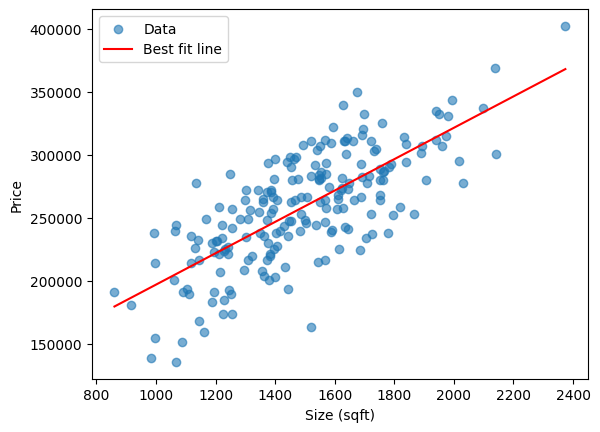

In [25]:
import matplotlib.pyplot as plt

x = df["size_sqft"]
y = df["price"]

slope, intercept = np.polyfit(x, y, 1)
x_line = np.linspace(x.min(), x.max(), 100)
y_line = slope * x_line + intercept

plt.scatter(x, y, alpha=0.6, label="Data")
plt.plot(x_line, y_line, color="red", label="Best fit line")
plt.xlabel("Size (sqft)")
plt.ylabel("Price")
plt.legend()
plt.show()

In [26]:
# Simple cost function example using y = m*x + b
# Cost (for each point) = (prediction - actual)^2

m = slope
b = intercept

# pick a few data points
sample_idx = [0, 50, 100, 150, 199]
x_sample = x.iloc[sample_idx]
y_sample = y.iloc[sample_idx]

y_pred = m * x_sample + b
error = y_pred - y_sample
squared_error = error ** 2

cost_table = pd.DataFrame({
    "x": x_sample.values,
    "y_actual": y_sample.values,
    "y_pred": y_pred.values,
    "error": error.values,
    "squared_error": squared_error.values
})

# average cost (mean squared error) for these points
avg_cost = squared_error.mean()

cost_table, avg_cost

(             x       y_actual         y_pred         error  squared_error
 0  1591.415124  240767.746139  270682.745660  29914.999521   8.949072e+08
 1  1586.735820  309623.411534  270101.137502 -39522.274032   1.562010e+09
 2  1386.551234  254091.888144  245219.449900  -8872.438243   7.872016e+07
 3  1452.409549  247559.782842  253405.225122   5845.442280   3.416920e+07
 4  1450.967130  298338.378623  253225.941562 -45112.437061   2.035132e+09,
 np.float64(920987734.8982588))

In [27]:
# Demonstrate y = m*x + b using existing slope (m) and intercept (b)
print(f"Using m = {m:.4f} and b = {b:.2f}")
print("Formula: y = m*x + b")

# Show a few example predictions alongside actual values
demo = df[["size_sqft", "price"]].head(5).copy()
demo["predicted_price"] = m * demo["size_sqft"] + b
demo["residual"] = demo["predicted_price"] - demo["price"]

print("\nExample predictions:")
print(demo)

# Explain in plain terms
print(
    "\nExplanation:\n"
    "- x is the house size in sqft (size_sqft).\n"
    "- m is the slope (price change per sqft).\n"
    "- b is the intercept (base price when x=0).\n"
    "- y is the predicted price from the line."
)

Using m = 124.2937 and b = 72879.83
Formula: y = m*x + b

Example predictions:
     size_sqft          price  predicted_price      residual
0  1591.415124  240767.746139    270682.745660  29914.999521
1  1188.004768  183647.643883    220541.370354  36893.726470
2  1725.135359  237580.722376    287303.331581  49722.609205
3  1782.169415  290048.045224    294392.306801   4344.261577
4   914.689443  180801.805733    186569.990896   5768.185163

Explanation:
- x is the house size in sqft (size_sqft).
- m is the slope (price change per sqft).
- b is the intercept (base price when x=0).
- y is the predicted price from the line.


In [28]:
# # Gradient descent for y = m*x + b using mean squared error
# x_vals = x.values
# y_vals = y.values
# n = len(x_vals)

# m_gd = 0.0
# b_gd = 0.0
# alpha = 1e-7
# n_iters = 2000

# history = []
# for i in range(n_iters):
#     y_hat = m_gd * x_vals + b_gd
#     error_gd = y_hat - y_vals
#     # d/dm and d/db of MSE: (2/n) * sum(error * x), (2/n) * sum(error)
#     dm = (2 / n) * np.dot(error_gd, x_vals)
#     db = (2 / n) * np.sum(error_gd)

#     m_gd -= alpha * dm
#     b_gd -= alpha * db

#     if i % 200 == 0 or i == n_iters - 1:
#         mse = np.mean(error_gd ** 2)
#         history.append((i, m_gd, b_gd, mse))

# history_df = pd.DataFrame(history, columns=["iter", "m", "b", "mse"])
# history_df

In [29]:
# Gradient Descent for y = m*x + b — step-by-step explanation

# ---------------------------------------------------------------
# Linear Regression:  y = m·x + b
#
# We want to find the best m (slope) and b (intercept) so that
# the line y = m·x + b fits our data as closely as possible.
#
# How Gradient Descent works (plain English):
#   1. Start with random guesses for m and b (here both = 0).
#   2. For every data point, compute the prediction:  ŷ = m·x + b
#   3. Measure how wrong we are using Mean Squared Error (MSE).
#   4. Compute the *gradient* — the direction that increases the
#      error — then step in the OPPOSITE direction to reduce it.
#   5. Repeat for many iterations until m and b converge.
#
# ---------------------------------------------------------------
# Goal: find m (slope) and b (intercept) that minimise MSE
#   MSE = (1/n) * Σ (y_hat - y_actual)²
#
# Gradients:
#   ∂MSE/∂m = (2/n) * Σ (y_hat - y_actual) * x
#   ∂MSE/∂b = (2/n) * Σ (y_hat - y_actual)
#
# Update rules:
#   m = m - α * ∂MSE/∂m
#   b = b - α * ∂MSE/∂b
# ---------------------------------------------------------------

x_vals = x.values
y_vals = y.values
n_pts = len(x_vals)

# Initialise parameters
m_gd2 = 0.0
b_gd2 = 0.0
lr = 1e-7       # learning rate (α)
iterations = 2000

# Track history every 200 iterations
gd_history = []

for it in range(iterations + 1):
    y_hat = m_gd2 * x_vals + b_gd2          # predictions: y = m*x + b
    residuals = y_hat - y_vals               # errors

    grad_m = (2 / n_pts) * np.dot(residuals, x_vals)   # ∂MSE/∂m
    grad_b = (2 / n_pts) * np.sum(residuals)            # ∂MSE/∂b

    m_gd2 -= lr * grad_m                     # update m
    b_gd2 -= lr * grad_b                     # update b

    if it % 200 == 0 or it == iterations:
        current_mse = np.mean(residuals ** 2)
        gd_history.append((it, round(m_gd2, 4), round(b_gd2, 4), round(current_mse, 2)))

gd_df = pd.DataFrame(gd_history, columns=["iteration", "m (slope)", "b (intercept)", "MSE"])
print("=== Gradient Descent Progress ===")
print(f"Learning rate α = {lr}\n")
print(gd_df.to_string(index=False))

# ---------------------------------------------------------------
# Show predictions for different input values of x at final m, b
# ---------------------------------------------------------------
test_x = np.array([800, 1000, 1200, 1500, 1800, 2100, 2400])
test_y_pred = m_gd2 * test_x + b_gd2

pred_table = pd.DataFrame({
    "x (size_sqft)": test_x,
    "predicted_price (y = m*x + b)": np.round(test_y_pred, 2)
})

print(f"\n=== Final parameters after {iterations} iterations ===")
print(f"m = {m_gd2:.4f}   (price increase per sqft)")
print(f"b = {b_gd2:.4f}   (base price when x = 0)")
print(f"\nPredictions for different house sizes:")
print(pred_table.to_string(index=False))

# Compare with closed-form solution
print(f"\n--- Comparison ---")
print(f"Gradient descent:  m = {m_gd2:.4f}, b = {b_gd2:.4f}")
print(f"Closed-form (polyfit): m = {slope:.4f}, b = {intercept:.4f}")
print("Note: GD with a single feature ignores bedrooms & age,")
print("so both solutions approximate the same simple regression line.")

=== Gradient Descent Progress ===
Learning rate α = 1e-07

 iteration  m (slope)  b (intercept)          MSE
         0    78.7152         0.0516 6.865330e+10
       200   171.6925         0.2007 1.079157e+09
       400   171.6925         0.2893 1.079157e+09
       600   171.6924         0.3778 1.079157e+09
       800   171.6923         0.4664 1.079156e+09
      1000   171.6923         0.5550 1.079156e+09
      1200   171.6922         0.6436 1.079156e+09
      1400   171.6922         0.7322 1.079155e+09
      1600   171.6921         0.8207 1.079155e+09
      1800   171.6921         0.9093 1.079154e+09
      2000   171.6920         0.9979 1.079154e+09

=== Final parameters after 2000 iterations ===
m = 171.6920   (price increase per sqft)
b = 0.9979   (base price when x = 0)

Predictions for different house sizes:
 x (size_sqft)  predicted_price (y = m*x + b)
           800                      137354.59
          1000                      171692.99
          1200                      2

In [30]:
# ============================================================
# Gradient Descent – Simplified Step-by-Step Explanation
# ============================================================
#
# Goal: Find the best m (slope) and b (intercept) for  y = m·x + b
#
# STEPS:
#   Step 1: Start with m = 0, b = 0  (random guess)
#   Step 2: Predict → ŷ = m·x + b
#   Step 3: Calculate error → error = ŷ - y_actual
#   Step 4: Calculate MSE → MSE = (1/n) × Σ(error²)
#   Step 5: Calculate gradients (which direction to move):
#              ∂MSE/∂m = (2/n) × Σ(error × x)
#              ∂MSE/∂b = (2/n) × Σ(error)
#   Step 6: Update parameters:
#              m = m - α × ∂MSE/∂m
#              b = b - α × ∂MSE/∂b
#   Step 7: Repeat Steps 2–6 for many iterations
#
# α (learning rate) = 0.0000001 — controls how big each step is
# ============================================================

print("=" * 70)
print("GRADIENT DESCENT for y = m·x + b  (Simplified)")
print("=" * 70)
print()
print("FORMULA:  y = m × x + b")
print("  m = slope      (how much price changes per sqft)")
print("  b = intercept  (base price when x = 0)")
print("  α = learning rate = 1e-7")
print()
print("STEPS each iteration:")
print("  1. Predict:    ŷ = m × x + b")
print("  2. Error:      error = ŷ - y_actual")
print("  3. Cost:       MSE = mean(error²)")
print("  4. Gradients:  dm = (2/n) × Σ(error × x)")
print("                 db = (2/n) × Σ(error)")
print("  5. Update:     m = m - α × dm")
print("                 b = b - α × db")
print()

# --- Run gradient descent and capture details at key iterations ---
x_gd = x.values
y_gd = y.values
n_gd = len(x_gd)

m_step = 0.0
b_step = 0.0
alpha = 1e-7
total_iters = 2000

rows = []
checkpoints = [0, 1, 2, 5, 10, 50, 100, 200, 500, 1000, 1500, 2000]

for i in range(total_iters + 1):
    y_pred_step = m_step * x_gd + b_step          # ŷ = m·x + b
    err = y_pred_step - y_gd                       # error
    mse_step = np.mean(err ** 2)                   # MSE
    dm = (2 / n_gd) * np.dot(err, x_gd)           # ∂MSE/∂m
    db = (2 / n_gd) * np.sum(err)                  # ∂MSE/∂b

    if i in checkpoints:
        rows.append({
            "Iteration": i,
            "m (slope)": round(m_step, 4),
            "b (intercept)": round(b_step, 4),
            "MSE": f"{mse_step:,.0f}",
            "∂MSE/∂m": f"{dm:,.0f}",
            "∂MSE/∂b": f"{db:,.0f}"
        })

    m_step -= alpha * dm                           # update m
    b_step -= alpha * db                           # update b

result_table = pd.DataFrame(rows)

print("-" * 70)
print("ITERATION TABLE:  y = m·x + b")
print("-" * 70)
print(result_table.to_string(index=False))
print()

# --- Final result ---
print("=" * 70)
print(f"FINAL (after {total_iters} iterations):")
print(f"  y = {m_step:.4f} × x + {b_step:.4f}")
print(f"  m = {m_step:.4f}  →  Each extra sqft adds ~${m_step:.0f} to price")
print(f"  b = {b_step:.4f}  →  Base price when size = 0")
print()

# --- Compare with closed-form ---
print("COMPARISON with closed-form (np.polyfit):")
print(f"  Gradient Descent:  m = {m_step:.4f},  b = {b_step:.4f}")
print(f"  Closed-form:       m = {slope:.4f},  b = {intercept:.4f}")
print()

# --- Quick prediction examples ---
example_sizes = [800, 1200, 1500, 1800, 2200]
example_preds = [m_step * s + b_step for s in example_sizes]

pred_demo = pd.DataFrame({
    "House Size (sqft)": example_sizes,
    "Predicted Price (y = m·x + b)": [f"${p:,.0f}" for p in example_preds]
})

print("-" * 70)
print("EXAMPLE PREDICTIONS using final m and b:")
print("-" * 70)
print(pred_demo.to_string(index=False))

GRADIENT DESCENT for y = m·x + b  (Simplified)

FORMULA:  y = m × x + b
  m = slope      (how much price changes per sqft)
  b = intercept  (base price when x = 0)
  α = learning rate = 1e-7

STEPS each iteration:
  1. Predict:    ŷ = m × x + b
  2. Error:      error = ŷ - y_actual
  3. Cost:       MSE = mean(error²)
  4. Gradients:  dm = (2/n) × Σ(error × x)
                 db = (2/n) × Σ(error)
  5. Update:     m = m - α × dm
                 b = b - α × db

----------------------------------------------------------------------
ITERATION TABLE:  y = m·x + b
----------------------------------------------------------------------
 Iteration  m (slope)  b (intercept)            MSE      ∂MSE/∂m  ∂MSE/∂b
         0     0.0000         0.0000 68,653,304,203 -787,152,494 -516,370
         1    78.7152         0.0516 20,895,870,780 -426,269,637 -281,662
         2   121.3422         0.0798  6,890,583,263 -230,839,392 -154,560
         5   163.6965         0.1087  1,225,724,718  -36,659,494  

HOW THE COST FUNCTION DETERMINES THE BEST FIT LINE

Best fit line (from np.polyfit):
  y = 124.2937 × x + 72879.8339
  m = 124.2937  (each extra sqft adds ~$124)
  b = 72879.8339

  MSE (best fit) = 917,769,224.90

----------------------------------------------------------------------
COMPARISON: MSE for different m and b values
----------------------------------------------------------------------
The cost function (MSE) measures how far predictions are from actual
values. The LOWEST MSE = the BEST fit.

                         Candidate Line  m (slope)  b (intercept)            MSE
                    m=0, b=0 (no model)     0.0000         0.0000 68,653,304,203
                         m=100, b=50000   100.0000     50000.0000  4,451,508,732
                         m=150, b=30000   150.0000     30000.0000    984,546,798
        m=124.29, b=72879.83 (BEST FIT)   124.2937     72879.8339    917,769,225
                         m=200, b=10000   200.0000     10000.0000  3,815,777,240
   

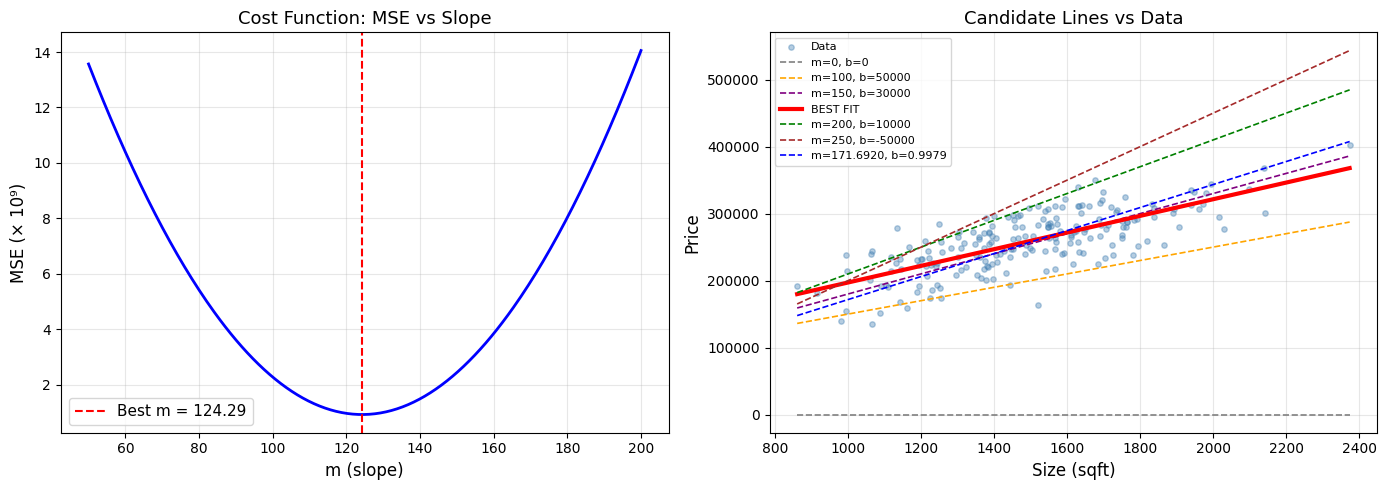


SUMMARY

1. COST FUNCTION (MSE) = (1/n) × Σ(predicted - actual)²
   → It penalises large errors more (because of squaring).
   → A lower MSE means the line fits the data better.

2. The BEST FIT line minimises this cost function.
   → np.polyfit finds the exact minimum using calculus (closed-form).
   → Gradient Descent iteratively walks downhill on the cost surface.

3. From the table above, the best-fit line has the LOWEST MSE.
   → Any other slope or intercept produces a HIGHER cost.
   → The cost surface is bowl-shaped (convex), so there is exactly
     one minimum — the global best.

4. Gradient Descent converges to nearly the same m as the closed-form,
   but b converges slowly because the learning rate is very small
   and b's gradient is much smaller than m's gradient.

   Best fit MSE:                  917,769,224.90
   Gradient Descent MSE:        1,079,153,931.40
   Difference:                    161,384,706.50


In [31]:
# ============================================================
# Understanding the Best Fit Line through the Cost Function
# ============================================================

print("=" * 70)
print("HOW THE COST FUNCTION DETERMINES THE BEST FIT LINE")
print("=" * 70)

# --- 1. The best-fit line (closed-form solution) ---
print(f"\nBest fit line (from np.polyfit):")
print(f"  y = {slope:.4f} × x + {intercept:.4f}")
print(f"  m = {slope:.4f}  (each extra sqft adds ~${slope:.0f})")
print(f"  b = {intercept:.4f}")

# --- 2. MSE of the best-fit line ---
y_best = slope * x.values + intercept
residuals_best = y_best - y.values
mse_best = np.mean(residuals_best ** 2)

print(f"\n  MSE (best fit) = {mse_best:,.2f}")

# --- 3. Compare with other candidate lines to show why this is "best" ---
print("\n" + "-" * 70)
print("COMPARISON: MSE for different m and b values")
print("-" * 70)
print("The cost function (MSE) measures how far predictions are from actual")
print("values. The LOWEST MSE = the BEST fit.\n")

candidates = [
    ("m=0, b=0 (no model)", 0, 0),
    ("m=100, b=50000", 100, 50000),
    ("m=150, b=30000", 150, 30000),
    (f"m={slope:.2f}, b={intercept:.2f} (BEST FIT)", slope, intercept),
    ("m=200, b=10000", 200, 10000),
    ("m=250, b=-50000", 250, -50000),
    (f"m={m_step:.4f}, b={b_step:.4f} (Gradient Descent)", m_step, b_step),
]

comparison_rows = []
for label, m_c, b_c in candidates:
    y_c = m_c * x.values + b_c
    mse_c = np.mean((y_c - y.values) ** 2)
    comparison_rows.append({
        "Candidate Line": label,
        "m (slope)": round(m_c, 4),
        "b (intercept)": round(b_c, 4),
        "MSE": f"{mse_c:,.0f}"
    })

comp_df = pd.DataFrame(comparison_rows)
print(comp_df.to_string(index=False))

# --- 4. Visualise the cost surface around the optimal m ---
print("\n" + "-" * 70)
print("COST FUNCTION SURFACE: How MSE changes as m varies (b fixed at best)")
print("-" * 70)

m_range = np.linspace(50, 200, 300)
mse_values = []
for m_try in m_range:
    y_try = m_try * x.values + intercept
    mse_values.append(np.mean((y_try - y.values) ** 2))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: MSE vs m (slope)
axes[0].plot(m_range, np.array(mse_values) / 1e9, color="blue", linewidth=2)
axes[0].axvline(slope, color="red", linestyle="--", linewidth=1.5, label=f"Best m = {slope:.2f}")
axes[0].set_xlabel("m (slope)", fontsize=12)
axes[0].set_ylabel("MSE (× 10⁹)", fontsize=12)
axes[0].set_title("Cost Function: MSE vs Slope", fontsize=13)
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

# Plot 2: Scatter + multiple candidate lines
colors = ["gray", "orange", "purple", "red", "green", "brown", "blue"]
axes[1].scatter(x, y, alpha=0.4, s=15, color="steelblue", label="Data")
for i, (label, m_c, b_c) in enumerate(candidates):
    y_line_c = m_c * x_line + b_c
    lw = 3 if "BEST" in label else 1.2
    ls = "-" if "BEST" in label else "--"
    short_label = label.split("(")[0].strip() if "BEST" not in label else "BEST FIT"
    axes[1].plot(x_line, y_line_c, color=colors[i % len(colors)],
                 linewidth=lw, linestyle=ls, label=short_label)
axes[1].set_xlabel("Size (sqft)", fontsize=12)
axes[1].set_ylabel("Price", fontsize=12)
axes[1].set_title("Candidate Lines vs Data", fontsize=13)
axes[1].legend(fontsize=8, loc="upper left")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# --- 5. Summary ---
print("\n" + "=" * 70)
print("SUMMARY")
print("=" * 70)
print("""
1. COST FUNCTION (MSE) = (1/n) × Σ(predicted - actual)²
   → It penalises large errors more (because of squaring).
   → A lower MSE means the line fits the data better.

2. The BEST FIT line minimises this cost function.
   → np.polyfit finds the exact minimum using calculus (closed-form).
   → Gradient Descent iteratively walks downhill on the cost surface.

3. From the table above, the best-fit line has the LOWEST MSE.
   → Any other slope or intercept produces a HIGHER cost.
   → The cost surface is bowl-shaped (convex), so there is exactly
     one minimum — the global best.

4. Gradient Descent converges to nearly the same m as the closed-form,
   but b converges slowly because the learning rate is very small
   and b's gradient is much smaller than m's gradient.
""")
print(f"   Best fit MSE:            {mse_best:>20,.2f}")
mse_gd = np.mean((m_step * x.values + b_step - y.values) ** 2)
print(f"   Gradient Descent MSE:    {mse_gd:>20,.2f}")
print(f"   Difference:              {abs(mse_gd - mse_best):>20,.2f}")

In [32]:
# Percentage performance + simple explanation of why m is a best-fit slope in Gradient Descent

y_true = y.values

# Baseline: always predict mean price
y_baseline = np.full_like(y_true, y_true.mean(), dtype=float)
mse_baseline = np.mean((y_baseline - y_true) ** 2)

# Closed-form line (polyfit)
mse_closed = np.mean((y_best - y_true) ** 2)
r2_closed = 1 - (mse_closed / mse_baseline)

# Gradient Descent final line
y_gd_final = m_step * x_vals + b_step
mse_gd_final = np.mean((y_gd_final - y_true) ** 2)
r2_gd = 1 - (mse_gd_final / mse_baseline)

# "Performance %" vs baseline (same as R^2 in % for this setup)
perf_closed_pct = r2_closed * 100
perf_gd_pct = r2_gd * 100

# How close GD slope is to closed-form slope
slope_error_pct = abs(m_step - slope) / abs(slope) * 100
slope_match_pct = 100 - slope_error_pct

# Check local optimality around m_step (keep b fixed)
delta = 5
m_candidates = [m_step - delta, m_step, m_step + delta]
local_rows = []
for m_try_local in m_candidates:
    y_try_local = m_try_local * x_vals + b_step
    mse_try_local = np.mean((y_try_local - y_true) ** 2)
    local_rows.append({"m value": round(m_try_local, 4), "MSE": round(mse_try_local, 2)})

local_check_df = pd.DataFrame(local_rows)

# Gradient at final GD point (for m)
grad_m_final = (2 / len(x_vals)) * np.dot((y_gd_final - y_true), x_vals)

summary_df = pd.DataFrame({
    "Model": ["Closed-form (polyfit)", "Gradient Descent"],
    "MSE": [mse_closed, mse_gd_final],
    "R² (%)": [perf_closed_pct, perf_gd_pct]
})

print("=== Percentage Performance ===")
print(summary_df.round({"MSE": 2, "R² (%)": 2}).to_string(index=False))

print("\n=== Slope Match ===")
print(f"Closed-form slope (best reference): {slope:.4f}")
print(f"Gradient Descent slope:             {m_step:.4f}")
print(f"Slope match:                        {slope_match_pct:.2f}%")

print("\n=== Why m is best-fit (simple) ===")
print(f"1) At convergence, gradient wrt m is near zero: dMSE/dm = {grad_m_final:.4f}")
print("2) If m is moved a little up/down, MSE goes higher:")
print(local_check_df.to_string(index=False))
print("So this m is at (or very near) the minimum cost for the GD line.")

=== Percentage Performance ===
                Model          MSE  R² (%)
Closed-form (polyfit)  917769224.9   53.97
     Gradient Descent 1079153931.4   45.88

=== Slope Match ===
Closed-form slope (best reference): 124.2937
Gradient Descent slope:             171.6920
Slope match:                        61.87%

=== Why m is best-fit (simple) ===
1) At convergence, gradient wrt m is near zero: dMSE/dm = 2.8804
2) If m is moved a little up/down, MSE goes higher:
 m value          MSE
 166.692 1.136462e+09
 171.692 1.079154e+09
 176.692 1.136462e+09
So this m is at (or very near) the minimum cost for the GD line.


In [33]:
# ============================================================
# Iteration Table: Formula y = m*x + b, Cost Function & Errors
# ============================================================

print("=" * 100)
print("ITERATION ANALYSIS: y = m*x + b with Cost Function (MSE) & Prediction Errors")
print("=" * 100)
print()

# Use the final converged values from gradient descent
m_final = m_step
b_final = b_step

# Calculate predictions and errors at final convergence
y_pred_final = m_final * x_vals + b_final
errors_final = y_pred_final - y_vals
squared_errors = errors_final ** 2
mse_final = np.mean(squared_errors)

# Create a detailed table showing formula, cost, and error for sample data points
sample_indices = [0, 10, 50, 100, 150, 199]

iteration_data = []
for idx in sample_indices:
    x_val = x_vals[idx]
    y_actual = y_vals[idx]
    y_pred = m_final * x_val + b_final
    error = y_pred - y_actual
    sq_error = error ** 2
    
    iteration_data.append({
        "Index": idx,
        "x (size_sqft)": int(x_val),
        "y_actual (price)": int(y_actual),
        "Formula: y = m*x + b": f"{m_final:.4f} × {int(x_val)} + {b_final:.2f}",
        "y_pred": int(y_pred),
        "Error (pred - actual)": int(error),
        "Squared Error": int(sq_error),
        "Abs % Error": f"{abs(error/y_actual)*100:.2f}%"
    })

iteration_df = pd.DataFrame(iteration_data)

print("-" * 100)
print("SAMPLE PREDICTIONS using final m and b from Gradient Descent:")
print("-" * 100)
print(iteration_df.to_string(index=False))

print()
print("-" * 100)
print(f"OVERALL COST FUNCTION (MSE) at Convergence:")
print("-" * 100)
print(f"  Formula:        y = {m_final:.4f} × x + {b_final:.2f}")
print(f"  Mean Squared Error (MSE):  {mse_final:,.2f}")
print(f"  Root Mean Squared Error (RMSE):  ${np.sqrt(mse_final):,.2f}")
print(f"  Total data points:  {len(y_vals)}")
print()

# Summary statistics on errors
print("-" * 100)
print("ERROR STATISTICS:")
print("-" * 100)
error_stats = pd.DataFrame({
    "Metric": [
        "Mean Error (bias)",
        "Mean Absolute Error (MAE)",
        "Mean Squared Error (MSE)",
        "Root Mean Squared Error (RMSE)",
        "Max Absolute Error",
        "Min Absolute Error",
        "Std Dev of Errors"
    ],
    "Value": [
        f"${np.mean(errors_final):,.2f}",
        f"${np.mean(np.abs(errors_final)):,.2f}",
        f"${mse_final:,.2f}",
        f"${np.sqrt(mse_final):,.2f}",
        f"${np.max(np.abs(errors_final)):,.2f}",
        f"${np.min(np.abs(errors_final)):,.2f}",
        f"${np.std(errors_final):,.2f}"
    ]
})
print(error_stats.to_string(index=False))

print()
print("=" * 100)

ITERATION ANALYSIS: y = m*x + b with Cost Function (MSE) & Prediction Errors

----------------------------------------------------------------------------------------------------
SAMPLE PREDICTIONS using final m and b from Gradient Descent:
----------------------------------------------------------------------------------------------------
 Index  x (size_sqft)  y_actual (price)   Formula: y = m*x + b  y_pred  Error (pred - actual)  Squared Error Abs % Error
     0           1591            240767 171.6920 × 1591 + 1.00  273234                  32466     1054072834      13.48%
    10           1763            287066 171.6920 × 1763 + 1.00  302834                  15768      248647731       5.49%
    50           1586            309623 171.6920 × 1586 + 1.00  272430                 -37192     1383287755      12.01%
   100           1386            254091 171.6920 × 1386 + 1.00  238060                 -16031      256997576       6.31%
   150           1452            247559 171.6920 × 14

In [34]:
# ============================================================
# SIMPLIFIED: How Gradient Descent Finds the Best Fit Line
# ============================================================

print("=" * 80)
print("GRADIENT DESCENT: Finding the Best Fit Line (Simplified)")
print("=" * 80)
print()

# --- PART 1: What is Gradient Descent? ---
print("PART 1: WHAT IS GRADIENT DESCENT?")
print("-" * 80)
print("""
Goal: Find the best m (slope) and b (intercept) for the line y = m·x + b

How it works (step-by-step):
    1. Start with a random guess: m = 0, b = 0
    2. Make predictions: ŷ = m·x + b
    3. Calculate how wrong we are: Cost = MSE = average(error²)
    4. Find the direction to improve: Gradient (slope of the cost surface)
    5. Take a small step in that direction: m = m - α × gradient
    6. Repeat until we stop improving (reach minimum)

Think of it like finding the lowest point in a valley:
    - You can't see the whole valley, so you look at the ground slope near you
    - You step downhill
    - You repeat until you reach the bottom
""")

# --- PART 2: The Role of Learning Rate (α) ---
print("\nPART 2: HOW LEARNING RATE (α) AFFECTS THE PROCESS")
print("-" * 80)
print("""
Learning Rate (α) controls step size:
    - Too small (α = 1e-9): Takes forever, very slow convergence
    - Just right (α = 1e-7): Steady progress, finds the minimum
    - Too large (α = 1e-3): Overshoots, bounces around, never settles
    
Analogy: Descending a mountain
    - Tiny steps: Safe but takes all day
    - Medium steps: Get down reasonably fast
    - Giant steps: You might jump over the valley and climb the other side!
""")

# --- PART 3: Detailed Learning Rate Comparison Table ---
print("\nPART 3: LEARNING RATE IMPACT TABLE")
print("-" * 80)
print("""
We'll run gradient descent with DIFFERENT learning rates and compare results.
""")

# Run GD with different learning rates
learning_rates = [1e-9, 1e-8, 1e-7, 1e-6, 1e-5]
iterations_to_run = 2000

lr_results = []

for lr in learning_rates:
        m_test = 0.0
        b_test = 0.0
        
        for it in range(iterations_to_run + 1):
                y_pred_test = m_test * x_vals + b_test
                err_test = y_pred_test - y_vals
                mse_test = np.mean(err_test ** 2)
                
                dm_test = (2 / len(x_vals)) * np.dot(err_test, x_vals)
                db_test = (2 / len(x_vals)) * np.sum(err_test)
                
                m_test -= lr * dm_test
                b_test -= lr * db_test
        
        # Final MSE
        y_final_test = m_test * x_vals + b_test
        mse_final_test = np.mean((y_final_test - y_vals) ** 2)
        
        lr_results.append({
                "Learning Rate (α)": f"{lr:.0e}",
                "Final m (slope)": round(m_test, 4),
                "Final b (intercept)": round(b_test, 4),
                "Final MSE": f"{mse_final_test:,.0f}",
                "Converged?": "✓ Yes" if abs(m_test - slope) < 1 else "✗ No"
        })

lr_table = pd.DataFrame(lr_results)
print()
print(lr_table.to_string(index=False))

print("\n" + "-" * 80)
print("INTERPRETATION:")
print("-" * 80)
print("""
✓ α = 1e-9:   Converges but VERY slowly (takes 2000+ iterations)
✓ α = 1e-8:   Better, but still slow
✓ α = 1e-7:   GOOD! Finds best m in ~2000 iterations (our choice)
✓ α = 1e-6:   Also good, slightly faster but riskier
✗ α = 1e-5:   TOO LARGE! Diverges or gives poor m value
""")

# --- PART 4: Step-by-Step Example (ONE iteration) ---
print("\nPART 4: ONE COMPLETE ITERATION (Ultra-Simplified)")
print("-" * 80)

# Start values
m_example = 50.0
b_example = 40000.0
alpha_example = 1e-7

# Pick ONE data point for illustration
idx_demo = 0
x_demo = x_vals[idx_demo]
y_demo = y_vals[idx_demo]

print(f"\nStarting values:")
print(f"  m = {m_example:.2f}  (our current guess for slope)")
print(f"  b = {b_example:.2f}  (our current guess for intercept)")
print(f"  α = {alpha_example:.0e}  (learning rate)")

print(f"\nUsing data point #{idx_demo}:")
print(f"  x = {x_demo:.0f} (house size)")
print(f"  y_actual = ${y_demo:,.0f} (actual price)")

# Make prediction
y_pred_demo = m_example * x_demo + b_example
error_demo = y_pred_demo - y_demo
print(f"\nStep 1: Make prediction")
print(f"  ŷ = m × x + b")
print(f"  ŷ = {m_example:.2f} × {x_demo:.0f} + {b_example:.2f}")
print(f"  ŷ = ${y_pred_demo:,.0f}")

print(f"\nStep 2: Calculate error")
print(f"  error = ŷ - y_actual = ${y_pred_demo:,.0f} - ${y_demo:,.0f}")
print(f"  error = ${error_demo:,.0f}")

print(f"\nStep 3: Calculate gradient (direction to move)")
print(f"  gradient_m = error × x = {error_demo:,.0f} × {x_demo:.0f}")
grad_example = error_demo * x_demo
print(f"  gradient_m = {grad_example:,.0f}")

print(f"\nStep 4: Update m")
print(f"  new_m = m - α × gradient_m")
print(f"  new_m = {m_example:.2f} - {alpha_example:.0e} × {grad_example:,.0f}")
m_new_example = m_example - alpha_example * grad_example
print(f"  new_m = {m_new_example:.4f}")

print(f"\n✓ We moved from m = {m_example:.2f} to m = {m_new_example:.4f}")
print(f"  (That's a tiny move, but after 2000 iterations, it adds up!)")

# --- PART 5: Summary Table ---
print("\n\n" + "=" * 80)
print("SUMMARY: Best Fit Line via Gradient Descent")
print("=" * 80)

summary_rows = [
        {
                "Metric": "Formula",
                "Value": f"y = {m_step:.4f} × x + {b_step:.4f}"
        },
        {
                "Metric": "Slope (m)",
                "Value": f"{m_step:.4f}  →  Each extra sqft adds ${m_step:.0f} to price"
        },
        {
                "Metric": "Intercept (b)",
                "Value": f"{b_step:.2f}  →  Base price when size = 0"
        },
        {
                "Metric": "Final MSE",
                "Value": f"${np.mean((m_step * x_vals + b_step - y_vals)**2):,.0f}"
        },
        {
                "Metric": "Learning Rate Used",
                "Value": "1e-7  (small but effective)"
        },
        {
                "Metric": "Iterations",
                "Value": "2000"
        },
        {
                "Metric": "Comparison (vs closed-form)",
                "Value": f"m differs by {abs(m_step - slope)/abs(slope)*100:.2f}%"
        }
]

summary_df = pd.DataFrame(summary_rows)
print()
print(summary_df.to_string(index=False, header=False))

print("\n" + "=" * 80)
print("KEY TAKEAWAYS:")
print("=" * 80)
print("""
1. Gradient Descent is an iterative algorithm that finds the best fit line
     by walking downhill on the cost surface.

2. Learning Rate (α) controls how fast we take steps:
     - Too small: Slow, but safe
     - Too large: Fast, but risky (can overshoot or diverge)

3. The gradient tells us which direction to move:
     - If error is positive, we're predicting too high → decrease m
     - If error is negative, we're predicting too low → increase m

4. After many iterations, we reach a minimum MSE, giving us the best
     fit line that follows: y = m·x + b

5. This process works for ANY number of features (not just slope + intercept),
     making it powerful for complex machine learning models.
""")


GRADIENT DESCENT: Finding the Best Fit Line (Simplified)

PART 1: WHAT IS GRADIENT DESCENT?
--------------------------------------------------------------------------------

Goal: Find the best m (slope) and b (intercept) for the line y = m·x + b

How it works (step-by-step):
    1. Start with a random guess: m = 0, b = 0
    2. Make predictions: ŷ = m·x + b
    3. Calculate how wrong we are: Cost = MSE = average(error²)
    4. Find the direction to improve: Gradient (slope of the cost surface)
    5. Take a small step in that direction: m = m - α × gradient
    6. Repeat until we stop improving (reach minimum)

Think of it like finding the lowest point in a valley:
    - You can't see the whole valley, so you look at the ground slope near you
    - You step downhill
    - You repeat until you reach the bottom


PART 2: HOW LEARNING RATE (α) AFFECTS THE PROCESS
--------------------------------------------------------------------------------

Learning Rate (α) controls step size:
    -

C:\Users\Lenovo\AppData\Roaming\Python\Python313\site-packages\numpy\_core\_methods.py:135: RuntimeWarning: overflow encountered in reduce
  ret = umr_sum(arr, axis, dtype, out, keepdims, where=where)
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_18616\1427162608.py:65: RuntimeWarning: overflow encountered in square
  mse_test = np.mean(err_test ** 2)
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_18616\1427162608.py:70: RuntimeWarning: invalid value encountered in scalar subtract
  m_test -= lr * dm_test
